# PA2: Personenerkennung auf dem PYNQ-Z1 — Custom-CNN + QAT + Pruning + hls4ml

**Modell:** Custom-CNN (5× MaxPool, kein DepthwiseConv2D, kein GlobalAveragePooling)  
**Optimierung:** QAT mit QKeras (6-Bit) + Pruning (50 % Sparsity, PolynomialDecay)  
**Zielplattform:** PYNQ-Z1 (Zynq-7020, 220 DSPs)  
**Referenz STM32:** MobileNetV2 TFLite-int8, 303 ms (Bachelorarbeit, Abb. 51 & 52)  

**Warum Custom-CNN statt MobileNetV2?**  
hls4ml verarbeitet `GlobalAveragePooling2D + io_stream` nicht korrekt (alle Outputs identisch). Wang et al. [FPL 2019] benötigen 4 RTL-Techniken auf einem ZCU102 (2520 DSPs). Das Custom-CNN umgeht alle Kompatibilitätsprobleme vollständig.

**Warum 5× MaxPool?**  
4× MaxPool → Flatten 6×6×64 = 2304 Inputs → Dense-Schicht zu groß für Vivado HLS Unrolling (XFORM 203-504). 5× MaxPool → 3×3×64 = 576 Inputs → synthetisierbar.

**Ablauf:**
1. Umgebung · 2. Datensatz · 3. Baseline-CNN · 4. Baseline-Training · 5. Pruning · 6. QKeras-Modell · 7. QAT+Pruning Training · 8. Vergleich · 9. hls4ml-Konvertierung · 10. CPU-Emulation · 11. Plattformvergleich · 12. Synthesebericht · 13. Synthese · 14. Deployment

## 1. Umgebung einrichten

In [1]:
# Vitis HLS 2022.2 —
import os
os.environ['PATH'] = '/tools/Xilinx/Vitis_HLS/2022.2/bin:' + os.environ['PATH']
!which vitis_hls

/tools/Xilinx/Vitis_HLS/2022.2/bin/vitis_hls


In [2]:
from tensorflow.keras.models import load_model
from qkeras.utils import _add_supported_quantized_objects

co = {}
_add_supported_quantized_objects(co)

#import os

#os.environ['PATH'] = os.environ['XILINX_VIVADO'] + '/bin:' + os.environ['PATH']

2026-07-02 23:50:00.502404: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
#!pip uninstall hls4ml==1.1.0
#!pip install hls4ml==1.1.0
!pip install keras

#print(f'hls4ml     : {hls4ml.__version__}')

## Die erforderliche Bibliothek importieren

In [4]:
import os, math, re, shutil, subprocess, time, glob, random
import keras
import numpy as np
import tensorflow as tf
import hls4ml
import pprint
import matplotlib; matplotlib.use('Agg')
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

# QKeras
from qkeras import QActivation, QDense, QConv2DBatchnorm
from qkeras.utils import _add_supported_quantized_objects

# Pruning
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity import keras as sparsity
from tensorflow_model_optimization.python.core.sparsity.keras import pruning_callbacks
from tensorflow_model_optimization.sparsity.keras import strip_pruning
from tensorflow_model_optimization.python.core.sparsity.keras import pruning_wrapper

from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization,
    Activation, MaxPooling2D, Flatten, Dense)
from tensorflow.keras.regularizers import l1
from tensorflow.keras.models import Model

co = {}; _add_supported_quantized_objects(co)
co['PruneLowMagnitude'] = pruning_wrapper.PruneLowMagnitude

random.seed(42); np.random.seed(42); tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'hls4ml     : {hls4ml.__version__}')


TensorFlow : 2.14.0
hls4ml     : 1.1.0


## MNIST Dataset importieren und Model definieren

In [ ]:
# train_model.py
import numpy as np
from qkeras import QActivation, QDense, QConv2DBatchnorm

# ── Load and resize to 8x8 ────────────────────────────────────────────────────
mnist = keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Resize from 28x28 to 8x8
import tensorflow as tf
x_train = tf.image.resize(x_train[..., np.newaxis], [8, 8]).numpy() / 255.0
x_test  = tf.image.resize(x_test[..., np.newaxis],  [8, 8]).numpy() / 255.0

# Für die CPU Emulation
np.save('x_test_8x8.npy', x_test[:500].astype(np.float32))
np.save('y_test.npy', y_test[:500])

print("Input shape:", x_train.shape)  # should be (60000, 8, 8, 1)

# ── Small CNN for 8x8 input ───────────────────────────────────────────────────
input_shape             = (8, 8, 1)
n_classes               = 10
filters_per_conv_layer  = [4, 8]

x = x_in = Input(shape=input_shape, name='img_input')

for i, f in enumerate(filters_per_conv_layer):
    x = QConv2DBatchnorm(
        int(f), kernel_size=(3, 3), strides=(1, 1),
        padding='same',
        kernel_quantizer='quantized_bits(6,0,alpha=1)',
        bias_quantizer='quantized_bits(6,0,alpha=1)',
        kernel_initializer='lecun_uniform',
        kernel_regularizer=l1(0.0001),
        use_bias=True,
        name='fused_convbn_{}'.format(i)
    )(x)
    x = QActivation('quantized_relu(6)', name='conv_act_%i' % i)(x)
    x = MaxPooling2D(pool_size=(2, 2), name='pool_{}'.format(i))(x)


x = Flatten(name='flatten')(x)


x = QDense(
    32,
    kernel_quantizer='quantized_bits(6,0,alpha=1)',
    kernel_initializer='lecun_uniform',
    kernel_regularizer=l1(0.0001),
    name='dense_0' ,
    use_bias=False
)(x)
x = BatchNormalization(name='bn_dense_{}'.format(i))(x)
x = QActivation('quantized_relu(6)', name='dense_act_0')(x)

x = QDense(
    int(n_classes),
    kernel_quantizer='quantized_bits(6,0,alpha=1)',
    bias_quantizer='quantized_bits(6,0,alpha=1)',
    kernel_initializer='lecun_uniform',
    name='output_dense'
)(x)
x_out = Activation('softmax', name='output_softmax')(x)

qmodel = Model(inputs=[x_in], outputs=[x_out], name='qkeras')

qmodel.summary()

Input shape: (60000, 8, 8, 1)
Model: "qkeras"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 img_input (InputLayer)      [(None, 8, 8, 1)]         0         
                                                                 
 fused_convbn_0 (QConv2DBat  (None, 8, 8, 4)           57        
 chnorm)                                                         
                                                                 
 conv_act_0 (QActivation)    (None, 8, 8, 4)           0         
                                                                 
 pool_0 (MaxPooling2D)       (None, 4, 4, 4)           0         
                                                                 
 fused_convbn_1 (QConv2DBat  (None, 4, 4, 8)           329       
 chnorm)                                                         
                                                                 
 conv_act_1 (QActivation)    (

## Prüfen, ob ein Layer zu Groß ist:

Die CNN-Implementierung in hls4ml basiert auf Streams, die in der Hardware als FIFO-Puffer (First-In-First-Out) synthetisiert werden. Mit Hilfe von Schieberegistern werden die letzten <Kernelhöhe - 1> Zeilen der Eingabepixel verfolgt und eine sich verschiebende Momentaufnahme des Faltungs-Kernels aufrechterhalten.

Zuletzt verwenden wir für alle Schichten in der hls4ml-Konfiguration [‚Strategy‘] = ‚Latency‘. Sollte eine Schicht mehr als 4096 Elemente haben, sollten wir für diese Schicht [‚Strategy‘] = ‚Resource‘ festlegen oder den Wiederverwendungsfaktor manuell erhöhen. 

In [6]:
for layer in qmodel.layers:
    if layer.__class__.__name__ in ['Conv2D', 'Dense']:
        w = layer.get_weights()[0]
        layersize = np.prod(w.shape)
        print("{}: {}".format(layer.name, layersize))  # 0 = weights, 1 = biases
        if layersize > 4096:  # assuming that shape[0] is batch, i.e., 'None'
            print("Layer {} is too large ({}), are you sure you want to train?".format(layer.name, layersize))

## Ausgabe alle Layer Größe

In [7]:
print("=== QKeras Modell — Layer-Größen ===")
for layer in qmodel.layers:
    if layer.__class__.__name__ in ['QConv2DBatchnorm', 'QDense', 'Conv2D', 'Dense']:
        w = layer.get_weights()[0]
        size = np.prod(w.shape)
        flag = ' ← ZU GROSS (Strategy=Resource)' if size > 4096 else ' ✓'
        print(f'{layer.name:30s}: {size:>8d}{flag}')

=== QKeras Modell — Layer-Größen ===
fused_convbn_0                :       36 ✓
fused_convbn_1                :      288 ✓
dense_0                       :     1024 ✓
output_dense                  :      320 ✓


## 9. hls4ml-Konvertierung

**Fixes gegenüber Standard:**
- `backend='Vivado'` + `part='xc7z020clg400-1'` direkt (kein `board='pynq-z2'` — Board-Definition fehlt in Vivado 2019.2)
- `ReuseFactor=576` für Dense (= Flatten-Output-Größe)
- QKeras-Modell: keine manuelle ap_fixed-Konfiguration nötig (hls4ml liest 6-bit-Annotationen automatisch)

In [8]:
!vivado -version

Vivado v2022.2 (64-bit)
SW Build 3671981 on Fri Oct 14 04:59:54 MDT 2022
IP Build 3669848 on Fri Oct 14 08:30:02 MDT 2022
Tool Version Limit: 2022.10
Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.


In [9]:
!vitis_hls -version

Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2022.2 (64-bit)
SW Build 3670227 on Oct 13 2022
IP Build 3669848 on Fri Oct 14 08:30:02 MDT 2022
Tool Version Limit: 2019.12
Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.


In [ ]:
import tensorflow as tf
import numpy as np
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.sparsity import keras as sparsity
from tensorflow_model_optimization.python.core.sparsity.keras import pruning_callbacks
from tensorflow_model_optimization.sparsity.keras import strip_pruning

# 1. Laden und Konvertieren von MNIST (Auflösung 8x8 – ideal für hls4ml)
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = tf.image.resize(x_train[..., np.newaxis], [8, 8]).numpy() / 255.0
x_test  = tf.image.resize(x_test[..., np.newaxis],  [8, 8]).numpy() / 255.0

# NSTEPS muss entsprechend der Größe Ihres Batches festgelegt werden (z. B.: len(x_train) // batch_size)
# Falls dieser Wert weiter oben nicht definiert wurde, können Sie hier einen Standardwert festlegen, z. B.: NSTEPS = 100

# ── Pruning-Funktion ──────────────────────────────────────────────────────────
#1. Definition der Trainings-Hyperparameter
BATCH_SIZE = 64
EPOCHS = 30

# 2. Automatische Berechnung der Anzahl der Schritte pro Epoche
# (len(x_train) * 0,9), da Sie validation_split=0,1 verwenden (d. h., 90 % der Daten werden für das Training verwendet)
NSTEPS = int(np.ceil((len(x_train) * 0.9) / BATCH_SIZE))
print(f"Nombre de steps par époque : {NSTEPS}")

# ── Pruning-Funktion ──────────────────────────────────────────────────────────
def pruneFunction(layer):
    pruning_params = {'pruning_schedule': sparsity.PolynomialDecay(
        initial_sparsity=0.0, final_sparsity=0.50,
        begin_step=NSTEPS * 2,       # Beginn bei Epoch=2
        end_step=NSTEPS * 10,       # Endet bei Epoch=10
        frequency=NSTEPS)}          # Update der Masken je Epoch
    
    if isinstance(layer, tf.keras.layers.Conv2D):
        return tfmot.sparsity.keras.prune_low_magnitude(layer, **pruning_params)
    if isinstance(layer, tf.keras.layers.Dense) and layer.name != 'output_dense':
        return tfmot.sparsity.keras.prune_low_magnitude(layer, **pruning_params)
    return layer
qmodel_pruned = tf.keras.models.clone_model(qmodel, clone_function=pruneFunction)

# Übertragung der Weight
for layer in qmodel.layers:
    try:
        tgt  = qmodel_pruned.get_layer(layer.name)
        ow   = layer.get_weights()
        tw   = tgt.get_weights()
        if ow and len(tw) >= len(ow):
            nw = list(tw)
            for i, w in enumerate(ow): nw[i] = w
            tgt.set_weights(nw)
    except: pass

# ── Training Konfiguration ───────────────────────────────────────────
#qmodel_pruned.compile(
 #   optimizer=tf.keras.optimizers.Adam(3e-4),
 #   loss='sparse_categorical_crossentropy',  
#    metrics=['accuracy']
#)

# Strenge Konfiguration der obligatorischen Callbacks
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=10, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint('qmodel_pruned_best.h5', monitor='val_accuracy', save_best_only=True),
    tfmot.sparsity.keras.UpdatePruningStep() # Hält die Pruning-Masken aktiv
]

# ── Einmaliger Start des Trainings ──────────────────────────────────────────────
#history = qmodel_pruned.fit(
#    x_train, 
#    y_train, 
 #   epochs=30, 
#    batch_size=64, 
 #   validation_split=0.1,
#    callbacks=callbacks # Correctement appliqué ici
#)

# [CORRECTION] La deuxième ligne .fit() brute a été supprimée pour éviter l'erreur d'assertion.

Nombre de steps par époque : 844
Epoch 1/30
844/844 [==============================] - 4s 3ms/step - loss: 1.8401 - accuracy: 0.4119 - val_loss: 1.3669 - val_accuracy: 0.6098
Epoch 2/30
 59/844 [=>............................] - ETA: 2s - loss: 1.3986 - accuracy: 0.5892

/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/engine/training.py:3079: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


844/844 [==============================] - 2s 3ms/step - loss: 1.1800 - accuracy: 0.6545 - val_loss: 0.9691 - val_accuracy: 0.7102
Epoch 3/30
844/844 [==============================] - 2s 3ms/step - loss: 0.9206 - accuracy: 0.7265 - val_loss: 0.8495 - val_accuracy: 0.7433
Epoch 4/30
844/844 [==============================] - 2s 3ms/step - loss: 0.8100 - accuracy: 0.7521 - val_loss: 0.9286 - val_accuracy: 0.6987
Epoch 5/30
844/844 [==============================] - 2s 3ms/step - loss: 0.8238 - accuracy: 0.7374 - val_loss: 0.9503 - val_accuracy: 0.6865
Epoch 6/30
844/844 [==============================] - 2s 3ms/step - loss: 0.8066 - accuracy: 0.7432 - val_loss: 1.0752 - val_accuracy: 0.6480
Epoch 7/30
844/844 [==============================] - 2s 3ms/step - loss: 0.8079 - accuracy: 0.7422 - val_loss: 1.5368 - val_accuracy: 0.5015
Epoch 8/30
844/844 [==============================] - 2s 3ms/step - loss: 0.9150 - accuracy: 0.7021 - val_loss: 0.7923 - val_accuracy: 0.7422
Epoch 9/30
844/84

In [11]:
qmodel_pruned   = tf.keras.models.load_model('qmodel_pruned_best.h5', custom_objects=co)
qmodel_stripped = strip_pruning(qmodel_pruned)
qmodel_stripped.save('qmodel_stripped.h5')

In [ ]:
 def divisors(n):
    """Alle Teiler von n, aufsteigend sortiert."""
    divs = set()
    i = 1
    while i * i <= n:
        if n % i == 0:
            divs.add(i); divs.add(n // i)
        i += 1
    return sorted(divs)

# 
def make_hls_config(model, default_precision='ap_fixed<16,5>'):
    # 1. Wir beginnen wieder mit einer soliden 16-Bit-Grundlage, um die Genauigkeit zu gewährleisten
    cfg = hls4ml.utils.config_from_keras_model(
        model, granularity='name', default_precision=default_precision)
    
    cfg['Model']['Strategy'] = 'Resource'
    #cfg['Model']['ReuseFactor'] = 999999   # Fallback max
    
    # Vivado dazu zwingen, für kleine Arrays und FIFOs LUTs (Distributed RAM) zu verwenden
    cfg['Model']['MemoryStorage'] = 'distributed'
    #cfg['Model']['Precision']   = 'ap_fixed<12,4>'
    cfg['Model']['ReuseFactor'] = 16
    #cfg['Model']['Strategy'] = 'Resource'

    #grau Zone 
    #conv layer und dense_0: 2**1 ist max--> 1 +1 --> ap_fixed<8,3>--> [-4;3,96875] 
    #hier z.b wurde ap_fixed<8,2> nicht reichend MAx=1,984375<2 sieh graph
    cfg['LayerName']['fused_convbn_0']['Precision']['weight']  = 'ap_fixed<8,3>'
    cfg['LayerName']['fused_convbn_0']['Precision']['bias']    = 'ap_fixed<8,3>'
    cfg['LayerName']['fused_convbn_0']['ReuseFactor'] = 9
    
    cfg['LayerName']['fused_convbn_1']['Precision']['weight']  = 'ap_fixed<8,3>'
    cfg['LayerName']['fused_convbn_1']['Precision']['bias']    = 'ap_fixed<8,3>'
    cfg['LayerName']['fused_convbn_1']['ReuseFactor'] = 9
    
    cfg['LayerName']['dense_0']['Precision']['weight'] = 'ap_fixed<8,3>'
    cfg['LayerName']['dense_0']['Precision']['bias']   = 'ap_fixed<8,3>'
    cfg['LayerName']['dense_0']['ReuseFactor'] = 9


    #bn_dense_1 : 2*4 ist das max-->4 + 1 = I = 5---> ap_fixed<12,5>
    cfg['LayerName']['bn_dense_1']['Precision']['weight'] = 'ap_fixed<8,5>'
    cfg['LayerName']['bn_dense_1']['Precision']['bias']   = 'ap_fixed<8,5>'
    
    cfg['LayerName']['output_dense']['ReuseFactor'] = 16
    cfg['LayerName']['output_dense']['Precision']['result'] = 'fixed<16,5,RND,SAT>'

            
    return cfg





# ── QAT + Pruning ─────────────────────────────────────────────────────────────
import shutil
OUT = 'model_personDetection/hls4ml_prj_qat'
shutil.rmtree(OUT, ignore_errors=True)

cfg_q = make_hls_config(qmodel_stripped)
#cfg_q['Flows'] = ['vivado:fifo_depth_optimization']
# Erzwingt eine reduzierte FIFO-Tiefe für das gesamte Modell
#cfg_q['Model']['FIFO_depth'] = 256   # statt default 2304 

hls_model_q = hls4ml.converters.convert_from_keras_model(
    qmodel_stripped, hls_config=cfg_q, output_dir=OUT,
    backend='Vitis', part='xc7z020clg400-1', io_type='io_stream'
)

#

hls_model_q.compile()

out_q = hls_model_q.predict(x_test[:100])
print(f'std={out_q[:,1].std():.4f}  kollaps={out_q[:,1].std()<1e-6}')

import numpy as np
out  = hls_model_q.predict(x_test[:500])
acc  = np.mean(np.argmax(out,axis=1) == y_test[:500])
print(f'Emu acc avec ap_fixed<12,4>: {acc*100:.1f}%')  


print('path:', os.path.abspath(OUT))


/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


Interpreting Model
Topology:
Layer name: img_input, layer type: InputLayer, input shapes: [[None, 8, 8, 1]], output shape: [None, 8, 8, 1]
Layer name: fused_convbn_0, layer type: QConv2DBatchnorm, input shapes: [[None, 8, 8, 1]], output shape: [None, 8, 8, 4]
Layer name: conv_act_0, layer type: Activation, input shapes: [[None, 8, 8, 4]], output shape: [None, 8, 8, 4]
Layer name: pool_0, layer type: MaxPooling2D, input shapes: [[None, 8, 8, 4]], output shape: [None, 4, 4, 4]
Layer name: fused_convbn_1, layer type: QConv2DBatchnorm, input shapes: [[None, 4, 4, 4]], output shape: [None, 4, 4, 8]
Layer name: conv_act_1, layer type: Activation, input shapes: [[None, 4, 4, 8]], output shape: [None, 4, 4, 8]
Layer name: pool_1, layer type: MaxPooling2D, input shapes: [[None, 4, 4, 8]], output shape: [None, 2, 2, 8]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 2, 2, 8]], output shape: [None, 32]
Layer name: dense_0, layer type: QDense, input shapes: [[None, 32]], output sha

In [ ]:
import numpy as np

# 1. Genauigkeit von reinem Keras (VOR hls4ml)
keras_out = qmodel_stripped.predict(x_test[:500])
keras_acc = np.mean(np.argmax(keras_out, axis=1) == y_test[:500])
print(f'Keras pur        : {keras_acc*100:.1f}%')

# 2. Zuweisung von Labels (der dir bekannte Klassenfehler)
print(f'Distribution y_val: {np.bincount(y_test[:500])}')   # erwartet ~[100,100]

# 3. Übereinstimmung zwischen Keras und HLS bei denselben Bildern
k = np.argmax(qmodel_stripped.predict(x_test[:500]), axis=1)
h = np.argmax(hls_model_q.predict(x_test[:500]), axis=1)
print(f'Accord Keras/HLS : {np.mean(k==h)*100:.0f}%')

16/16 [==============================] - 0s 959us/step
Keras pur        : 80.6%
Distribution y_val: [42 67 55 45 55 50 43 49 40 54]
16/16 [==============================] - 0s 966us/step
Accord Keras/HLS : 98%


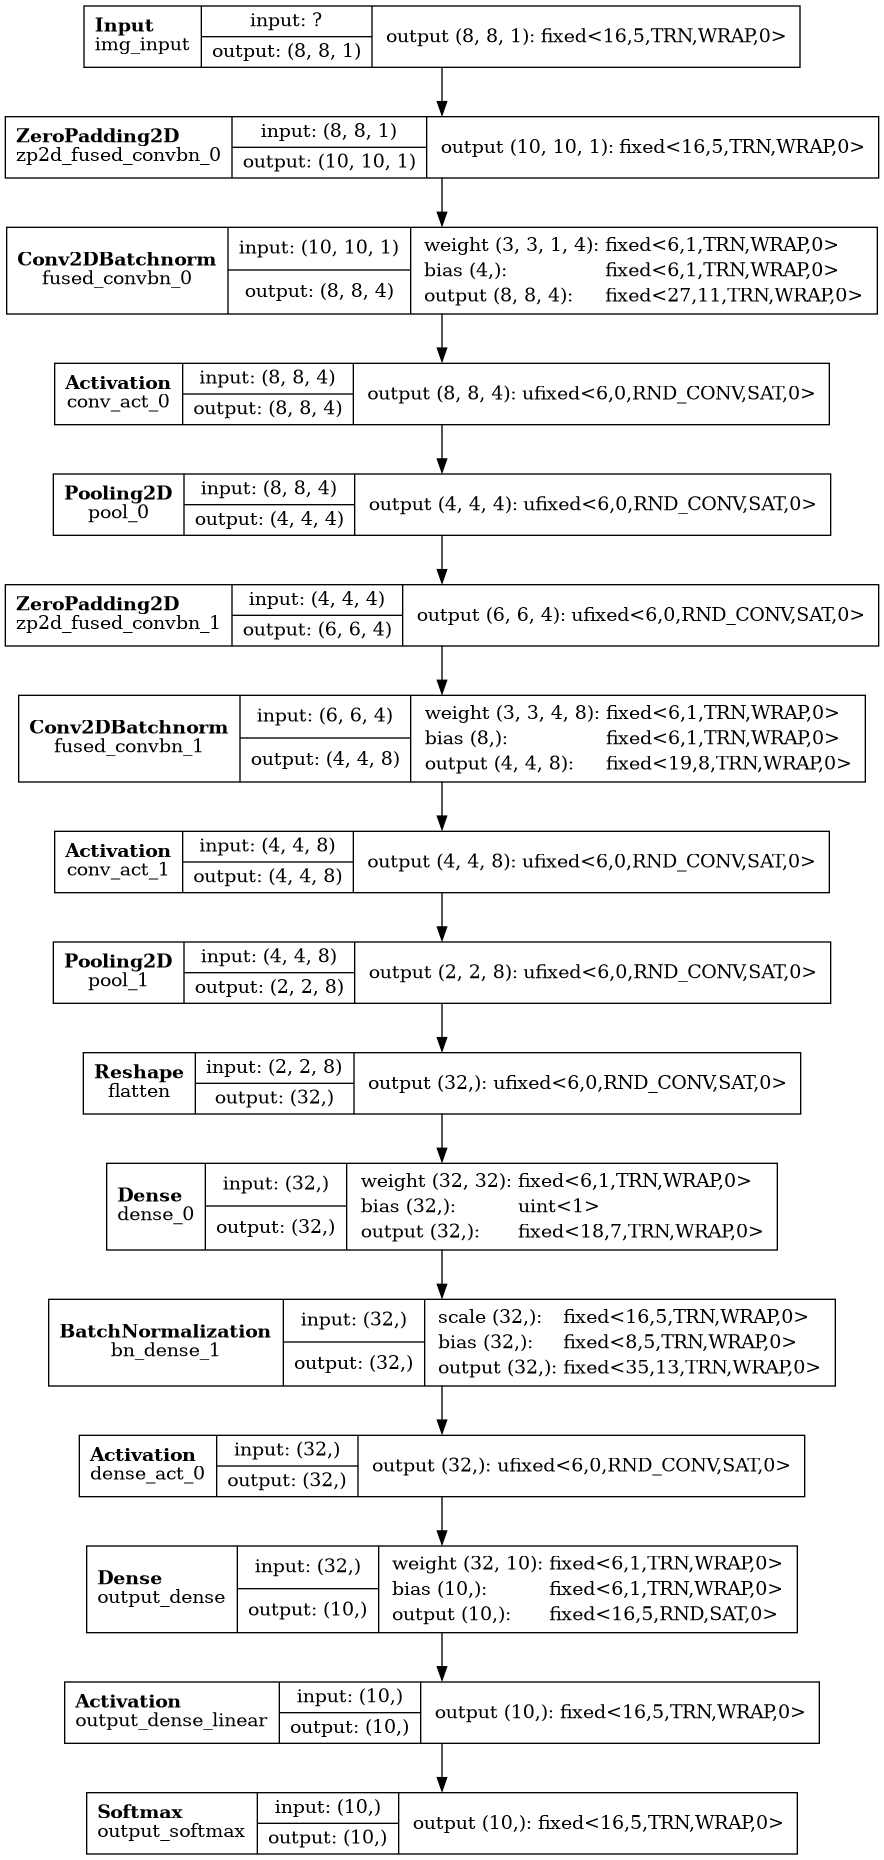

In [20]:
hls4ml.utils.plot_model(hls_model_q, show_shapes=True, show_precision=True, to_file=None)

Interpreting Model
Topology:
Layer name: img_input, layer type: InputLayer, input shapes: [[None, 8, 8, 1]], output shape: [None, 8, 8, 1]
Layer name: fused_convbn_0, layer type: QConv2DBatchnorm, input shapes: [[None, 8, 8, 1]], output shape: [None, 8, 8, 4]
Layer name: conv_act_0, layer type: Activation, input shapes: [[None, 8, 8, 4]], output shape: [None, 8, 8, 4]
Layer name: pool_0, layer type: MaxPooling2D, input shapes: [[None, 8, 8, 4]], output shape: [None, 4, 4, 4]
Layer name: fused_convbn_1, layer type: QConv2DBatchnorm, input shapes: [[None, 4, 4, 4]], output shape: [None, 4, 4, 8]
Layer name: conv_act_1, layer type: Activation, input shapes: [[None, 4, 4, 8]], output shape: [None, 4, 4, 8]
Layer name: pool_1, layer type: MaxPooling2D, input shapes: [[None, 4, 4, 8]], output shape: [None, 2, 2, 8]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 2, 2, 8]], output shape: [None, 32]
Layer name: dense_0, layer type: QDense, input shapes: [[None, 32]], output sha

/home/yvan/miniconda3/envs/hls4ml-tutorial/lib/python3.10/site-packages/keras/src/constraints.py:365: UserWarning: The `keras.constraints.serialize()` API should only be used for objects of type `keras.constraints.Constraint`. Found an instance of type <class 'qkeras.quantizers.quantized_bits'>, which may lead to improper serialization.
  warnings.warn(


(<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 None,
 None)

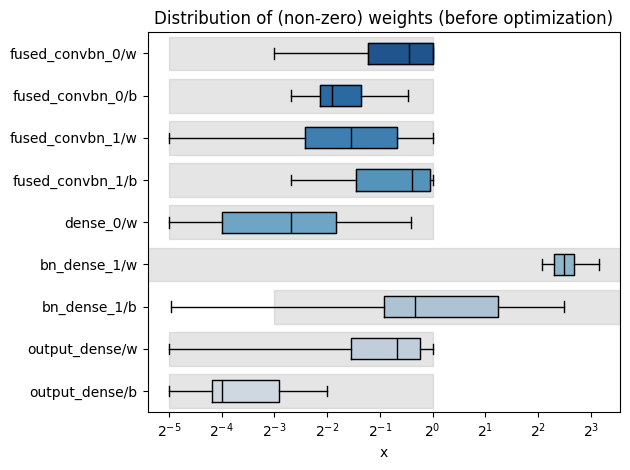

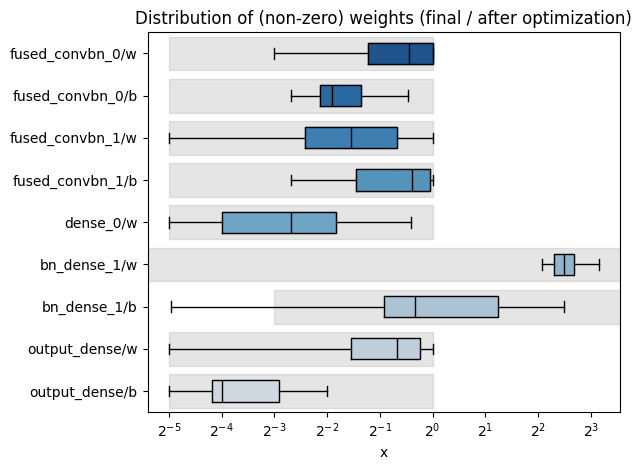

In [21]:
import matplotlib.pyplot as plt
from hls4ml.model.profiling import numerical
%matplotlib inline

numerical(model=qmodel_stripped, hls_model=hls_model_q)

#conv layer und dense_0: 2**1 ist max--> 1 +1 --> ap_fixed<8,3>--> [-4;3,96875] hier z.b wurde ap_fixed<8,2> nicht reichend MAx=1,984375<2 sieh graph
#bn_dense_1 : 2**4 ist das max-->4 + 1 = I = 5---> ap_fixed<12,5>--> [-2^(5-1);+2^(5-1)-2^(-12+5)]-->Max;Min=[-16;+15,9921875]

In [16]:
import pprint
pprint.pprint(hls4ml.backends.get_backend('VivadoAccelerator').create_initial_config('fpga', part='xc7z020clg400-1',  clock_period=5, io_type='io_stream'))

{'AcceleratorConfig': {'Board': 'fpga',
                       'Driver': 'python',
                       'Interface': 'axi_stream',
                       'Precision': {'Input': 'float', 'Output': 'float'}},
 'ClockPeriod': 5,
 'ClockUncertainty': '12.5%',
 'HLSConfig': {},
 'IOType': 'io_stream',
 'Part': 'xc7z020clg400-1',
 'WriterConfig': {'Namespace': None,
                  'WriteTar': False,
                  'WriteWeightsTxt': True}}


In [ ]:
import numpy as np

# 1. Genauigkeit von reinem Keras (VOR hls4ml)
keras_out = qmodel_stripped.predict(x_test[:500])
keras_acc = np.mean(np.argmax(keras_out, axis=1) == y_test[:500])
print(f'Keras pur        : {keras_acc*100:.1f}%')

# 2. Zuweisung von Labels (der dir bekannte Klassenfehler)
print(f'Distribution y_val: {np.bincount(y_test[:500])}')   # erwartet ~[100,100]

# 3. Übereinstimmung zwischen Keras und HLS bei denselben Bildern
k = np.argmax(qmodel_stripped.predict(x_test[:500]), axis=1)
h = np.argmax(hls_model_q.predict(x_test[:500]), axis=1)
print(f'Accord Keras/HLS : {np.mean(k==h)*100:.0f}%')

16/16 [==============================] - 0s 1ms/step
Keras pur        : 80.6%
Distribution y_val: [42 67 55 45 55 50 43 49 40 54]
16/16 [==============================] - 0s 953us/step
Accord Keras/HLS : 98%


In [ ]:
# ── Automatischer Start der Synthese ──────────────────────────────────────
print("\n[INFO] Start der Vivado-HLS-Synthese (einschließlich IP-Export)...")
# Starte die vollständige C-Synthese und exportiere den IP-Block (.zip) für Vivado Vivado
hls_model_q.build(reset=True, csim=False, synth=True, vsynth=True, export=True)
#hls_model_q.build(csim=False,cosim=False, synth=True, export=True)


[INFO] Lancement de la synthèse Vivado HLS (export IP inclus)...


Exception: Vitis HLS installation not found. Make sure "vitis_hls" is on PATH.